In [7]:
import math 
import numpy as np
import matplotlib.pyplot as plt
import afterglowpy as grb


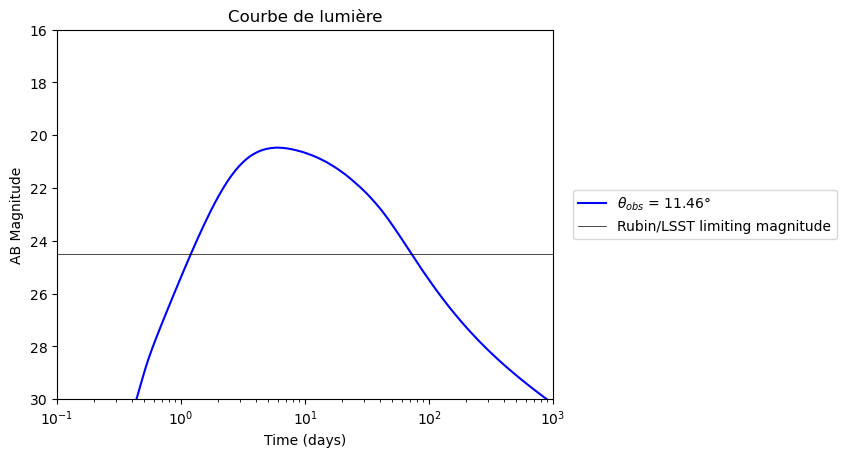

In [15]:
Z = {'jetType':     grb.jet.TopHat,     # Jet Type
     'specType':    0,                  # Basic Synchrotron Emission Spectrum
     'b':           4,      # Power Law index
     'thetaObs':    0.2,   # Viewing angle
     'E0':          1.0e54, # Isotropic-equivalent energy in erg
     'thetaWing':   0.15,    # Truncation angle
     'thetaCore':   0.1,   # Half-opening angle in radians
     'n0':          1.0,    # Circumburst density in cm^{-3}
     'p':           2.2,    # Electron energy distribution index
     'epsilon_e':   0.1,    # epsilon_e
     'epsilon_B':   0.01,   # epsilon_B
     'xi_N':        1.0,    # Fraction of electrons accelerated
     'd_L':         1.0e28, # Luminosity distance in cm
     'z':           0.55}   # Redshift

# Space time points geometrically, from 10^3 s to 10^9 s
t = np.geomspace(1.0e3, 1.0e8, 300)

# Calculate flux in optical (all times have same frequency)
nu = np.empty(t.shape)
nu[:] = 5.0e14

# Calcul de la courbe de lumière du sursaut gamma avec la configuration "Z"
# pour tous les temps dans le tableau t
# et pour une fréquence de 5e14 Hz (~vert)
light_curve = grb.fluxDensity(t, nu, **Z)

# conversion du flux en mJy en magnitude
mag = -2.5 * np.log10(light_curve*1.0e-26) - 48.6

# plot de la courbe de lumière
plt.plot(t*grb.sec2day, mag, label = r'$\theta_{obs}$ = %.2f°' %
         (math.degrees(Z['thetaObs'])), color='b')

plt.title('Courbe de lumière')
plt.xlabel('Time (days)')
plt.ylabel('AB Magnitude')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.xlim(0.1, 1000)
plt.ylim(30,16)
plt.axhline(y=24.5, color='black', linewidth='0.5', label='Rubin/LSST limiting magnitude')
plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)

plt.show()